# 04 – Model Interpretation and Robustness Analysis

## Objective

This notebook investigates how the final machine-learning model behaves after model development and evaluation.

Notebook 03 established that the Random Forest Classifier was selected as the final model based on its highest mean cross-validation F1 score among the evaluated models.

The final model and its hyperparameters were fixed before beginning the analyses in this notebook. Notebook 04 does not retrain the model, tune hyperparameters, select a different model, or optimize a final classification threshold.

Instead, this notebook focuses on interpreting the behavior of the final Random Forest model and examining the reliability of its predictive patterns.

The following questions are investigated:

1. How stable is the model's performance across cross-validation folds?
2. Which stellar properties does the model rely on most strongly?
3. How do the model's predictions change as important stellar features vary?
4. How strongly does the model favor one class over the other for individual observations?
5. Which types of observations are most difficult for the model to classify correctly?

These analyses distinguish predictive performance from scientific interpretation.

Feature importance and model-response analyses describe how the fitted model uses the available predictors. They do not establish that any stellar property causally determines whether an exoplanet is a gas giant.

Probability calibration is not evaluated in this notebook. The reliability of the model's predicted probabilities is investigated separately in Notebook 05.

In [46]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [47]:
best_model = joblib.load(
    "../models/random_forest.joblib"
)

X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

print(
    "Training data shape:",
    X_train.shape
)

print(
    "Testing data shape:",
    X_test.shape
)

print(
    "Model type:",
    type(best_model)
)

Training data shape: (22032, 3)
Testing data shape: (5508, 3)
Model type: <class 'sklearn.pipeline.Pipeline'>


In [48]:
EXPECTED_FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

assert list(X_train.columns) == EXPECTED_FEATURES
assert list(X_test.columns) == EXPECTED_FEATURES

assert list(X_train.columns) == list(
    X_test.columns
)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert set(y_train.unique()) <= {0, 1}
assert set(y_test.unique()) <= {0, 1}

assert "imputer" in best_model.named_steps
assert "model" in best_model.named_steps

assert (
    type(
        best_model.named_steps["model"]
    ).__name__
    == "RandomForestClassifier"
)

print(
    "Model and dataset integrity checks passed."
)

Model and dataset integrity checks passed.


In [49]:
final_model_parameters = {
    parameter: value
    for parameter, value in (
        best_model
        .named_steps["model"]
        .get_params()
        .items()
    )
    if parameter in [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "class_weight",
        "random_state"
    ]
}

final_model_parameters

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100,
 'random_state': 42}

## Final Test-Set Performance

The final Random Forest model is evaluated on the untouched testing dataset.

The test set was not used for hyperparameter selection or model selection in Notebook 03.

The following metrics are reported:

- Accuracy
- Precision
- Recall
- F1 score
- ROC-AUC
- Average Precision

The probability-based metrics use the predicted probability of the positive class, defined as the radius-based gas-giant class.

In [53]:
y_pred = best_model.predict(
    X_test
)

y_probability = (
    best_model
    .predict_proba(X_test)[:, 1]
)

In [52]:
test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ],
    "Score": [
        accuracy_score(
            y_test,
            y_pred
        ),
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            y_probability
        ),
        average_precision_score(
            y_test,
            y_probability
        )
    ]
})

test_metrics.round(3)

,Metric,Score
0,Accuracy,0.854
1,Precision,0.509
2,Recall,0.595
3,F1,0.549
4,ROC-AUC,0.865
5,Average Precision,0.579


In [54]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Gas Giant",
            "Gas Giant"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Non-Gas Giant       0.93      0.90      0.91      4686
    Gas Giant       0.51      0.59      0.55       822

     accuracy                           0.85      5508
    macro avg       0.72      0.75      0.73      5508
 weighted avg       0.86      0.85      0.86      5508



## Cross-Validation Stability

Notebook 03 used five-fold stratified cross-validation during model development.

Here, the fixed final Random Forest pipeline is evaluated again using the same cross-validation structure to examine how consistently its performance varies across folds.

The mean and standard deviation of each metric are reported.

A smaller standard deviation indicates less variation across the evaluated folds. However, variation across five folds should be interpreted as an estimate of performance variability within this dataset rather than as a formal population-level uncertainty interval.

In [55]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision":
            "average_precision"
    },
    n_jobs=-1
)

In [56]:
cv_scores = pd.DataFrame({
    "Fold": range(1, 6),

    "Accuracy":
        cv_results["test_accuracy"],

    "Precision":
        cv_results["test_precision"],

    "Recall":
        cv_results["test_recall"],

    "F1":
        cv_results["test_f1"],

    "ROC-AUC":
        cv_results["test_roc_auc"],

    "Average Precision":
        cv_results[
            "test_average_precision"
        ]
})

cv_scores.round(3)

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,1,0.848,0.491,0.592,0.537,0.859,0.585
1,2,0.842,0.477,0.593,0.529,0.847,0.515
2,3,0.847,0.489,0.557,0.521,0.842,0.519
3,4,0.855,0.512,0.586,0.546,0.853,0.557
4,5,0.852,0.505,0.592,0.545,0.853,0.543


In [57]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision"
]

cv_summary = pd.DataFrame({
    "Metric": metric_columns,

    "Mean": [
        cv_scores[metric].mean()
        for metric in metric_columns
    ],

    "Standard Deviation": [
        cv_scores[metric].std(ddof=0)
        for metric in metric_columns
    ],

    "Minimum": [
        cv_scores[metric].min()
        for metric in metric_columns
    ],

    "Maximum": [
        cv_scores[metric].max()
        for metric in metric_columns
    ]
})

cv_summary.round(3)

,Metric,Mean,Standard Deviation,Minimum,Maximum
0,Accuracy,0.849,0.004,0.842,0.855
1,Precision,0.495,0.012,0.477,0.512
2,Recall,0.584,0.014,0.557,0.593
3,F1,0.536,0.010,0.521,0.546
4,ROC-AUC,0.851,0.006,0.842,0.859
5,Average Precision,0.544,0.026,0.515,0.585


In [59]:
cv_f1_range = (
    cv_scores["F1"].max()
    -
    cv_scores["F1"].min()
)

print(
    "Cross-validation F1 range:",
    round(cv_f1_range, 3)
)

Cross-validation F1 range: 0.026


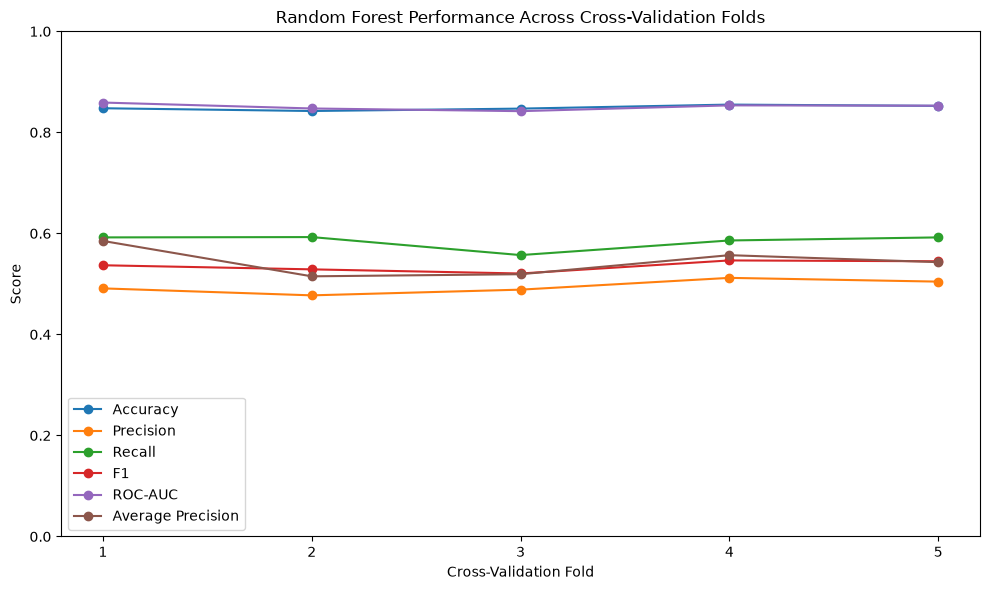

In [60]:
plt.figure(figsize=(10, 6))

for metric in metric_columns:

    plt.plot(
        cv_scores["Fold"],
        cv_scores[metric],
        marker="o",
        label=metric
    )

plt.xlabel(
    "Cross-Validation Fold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Random Forest Performance Across Cross-Validation Folds"
)

plt.xticks(
    cv_scores["Fold"]
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

plt.show()

## Random Forest Feature Importance

Random Forest impurity-based feature importance measures how much each feature contributes to reducing classification impurity across the decision trees in the ensemble.

These values describe how the model uses the features internally.

However, impurity-based importance can be affected by the structure and distribution of predictors. Therefore, it is treated as a model-specific interpretation rather than definitive evidence of independent feature importance or causation.

In [61]:
rf_importance = pd.DataFrame({
    "Feature": X_test.columns,

    "Importance":
        best_model
        .named_steps["model"]
        .feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_importance

,Feature,Importance
0,st_rad,0.408478
1,st_teff,0.383826
2,st_met,0.207696


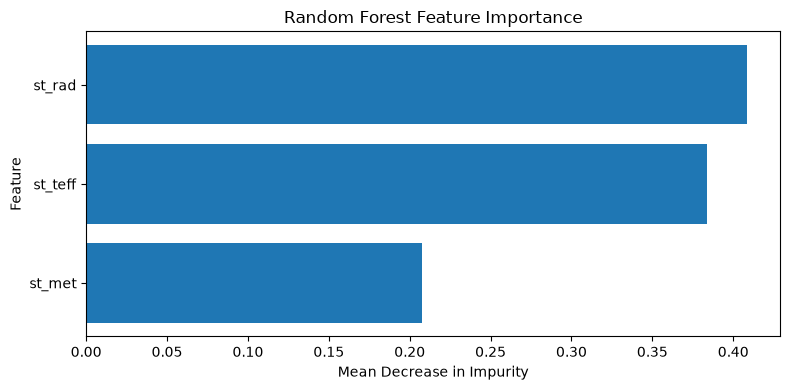

In [62]:
plt.figure(figsize=(8, 4))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel(
    "Mean Decrease in Impurity"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Permutation Feature Importance

Permutation importance evaluates how much model performance decreases when the values of one feature are randomly shuffled.

If shuffling a feature causes a large decrease in performance, the model relied substantially on that feature for prediction.

Permutation importance complements the Random Forest's internal impurity-based importance by evaluating the fitted model's predictive performance after disrupting one feature.

Because this analysis uses a finite held-out test set and only three predictors, the resulting rankings should be interpreted as evidence of predictive reliance rather than precise estimates of independent causal contribution.

Permutation importance may also be affected by correlated or redundant predictors. If two features contain overlapping information, shuffling one feature may produce a smaller performance decrease even if the underlying information remains important to the model.

In [63]:
permutation_f1 = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_f1_df = pd.DataFrame({
    "Feature": X_test.columns,

    "Mean F1 Decrease":
        permutation_f1.importances_mean,

    "F1 Decrease Standard Deviation":
        permutation_f1.importances_std
})

permutation_f1_df = (
    permutation_f1_df
    .sort_values(
        "Mean F1 Decrease",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_f1_df.round(4)

,Feature,Mean F1 Decrease,F1 Decrease Standard Deviation
0,st_rad,0.2933,0.0079
1,st_teff,0.2370,0.0083
2,st_met,0.2188,0.0084


In [64]:
permutation_auc = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_auc_df = pd.DataFrame({
    "Feature": X_test.columns,

    "Mean ROC-AUC Decrease":
        permutation_auc.importances_mean,

    "ROC-AUC Decrease Standard Deviation":
        permutation_auc.importances_std
})

permutation_auc_df = (
    permutation_auc_df
    .sort_values(
        "Mean ROC-AUC Decrease",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_auc_df.round(4)

,Feature,Mean ROC-AUC Decrease,ROC-AUC Decrease Standard Deviation
0,st_rad,0.2679,0.0071
1,st_teff,0.2013,0.0076
2,st_met,0.1661,0.0064


In [65]:
importance_comparison = (
    rf_importance[
        [
            "Feature",
            "Importance"
        ]
    ]
    .merge(
        permutation_f1_df[
            [
                "Feature",
                "Mean F1 Decrease"
            ]
        ],
        on="Feature"
    )
    .merge(
        permutation_auc_df[
            [
                "Feature",
                "Mean ROC-AUC Decrease"
            ]
        ],
        on="Feature"
    )
)

importance_comparison

,Feature,Importance,Mean F1 Decrease,Mean ROC-AUC Decrease
0,st_rad,0.408478,0.293291,0.267924
1,st_teff,0.383826,0.237013,0.201337
2,st_met,0.207696,0.218828,0.166130


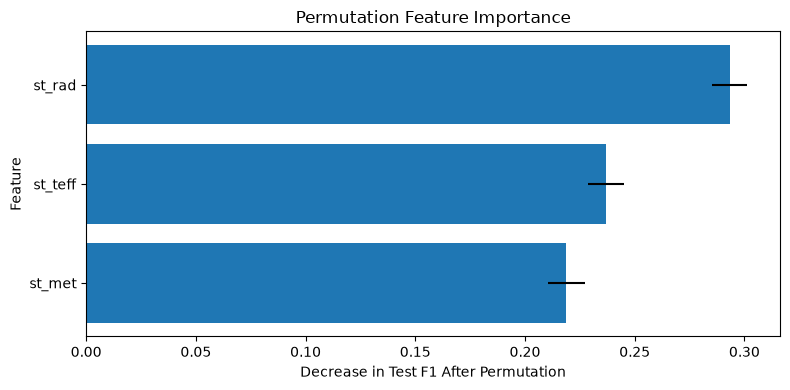

In [66]:
plt.figure(figsize=(8, 4))

plt.barh(
    permutation_f1_df["Feature"],
    permutation_f1_df["Mean F1 Decrease"],
    xerr=permutation_f1_df[
        "F1 Decrease Standard Deviation"
    ]
)

plt.xlabel(
    "Decrease in Test F1 After Permutation"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Permutation Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Partial Dependence Analysis

Partial dependence analysis examines how the model's average predicted probability of the gas-giant class changes as a feature varies.

This analysis helps investigate whether the model's learned relationship with a stellar property appears approximately:

- increasing,
- decreasing,
- nonlinear,
- or relatively weak.

Partial dependence describes the behavior of the fitted model. It should not be interpreted as evidence that changing a stellar property would causally change planetary composition.

When predictors are correlated, some combinations of feature values may be uncommon or unrealistic. Therefore, these plots describe the model's learned response surface rather than physically independent changes in stellar properties.

In [67]:
features_to_plot = (
    permutation_f1_df
    .head(3)["Feature"]
    .tolist()
)

features_to_plot

['st_rad', 'st_teff', 'st_met']

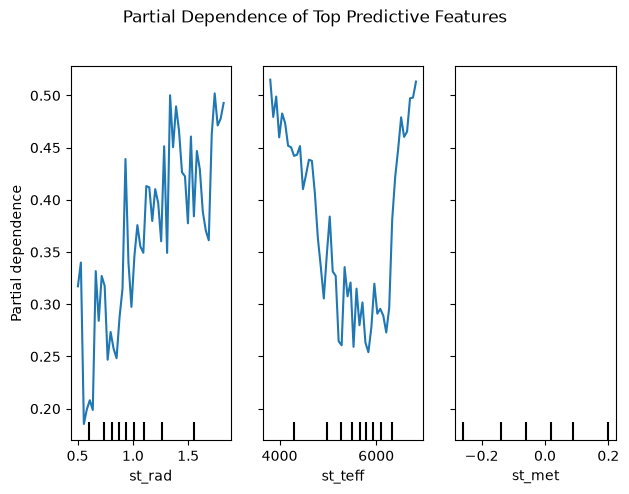

In [68]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features_to_plot,
    kind="average",
    grid_resolution=50
)

plt.suptitle(
    "Partial Dependence of Top Predictive Features",
    y=1.02
)

plt.tight_layout()

plt.show()

## Prediction Probability and Decision-Margin Analysis

The Random Forest produces a predicted probability for each observation in addition to a binary class prediction.

These predicted probabilities are used here to examine how strongly the model favors one class over the other.

The quantity called the decision margin is defined as the absolute distance between the predicted gas-giant probability and the default 0.50 classification threshold.

A smaller decision margin indicates that the prediction is closer to the classification boundary.

A larger decision margin indicates a stronger model preference for one class.

These values should not be interpreted as calibrated probabilities of correctness. Probability calibration is evaluated separately in Notebook 05.

In [69]:
probability_analysis = X_test.copy()

probability_analysis[
    "Actual"
] = y_test.values

probability_analysis[
    "Predicted"
] = y_pred

probability_analysis[
    "Gas Giant Probability"
] = y_probability

probability_analysis[
    "Correct"
] = (
    probability_analysis["Actual"]
    ==
    probability_analysis["Predicted"]
)

probability_analysis[
    "Decision Margin"
] = abs(
    probability_analysis[
        "Gas Giant Probability"
    ]
    -
    0.5
)

probability_analysis.head()

,st_teff,st_rad,st_met,Actual,Predicted,Gas Giant Probability,Correct,Decision Margin
0,5400.0,1.09539,NaN,1,1,0.750750,True,0.250750
1,5094.0,0.87000,0.16,0,0,0.023333,True,0.476667
2,3270.0,0.21050,NaN,0,0,0.000000,True,0.500000
3,5763.0,1.08600,0.05,0,0,0.020000,True,0.480000
4,4840.0,1.05000,0.06,1,0,0.454444,False,0.045556


In [70]:
probability_analysis[
    "Decision Margin"
].describe().round(3)

count    5508.000
mean        0.376
std         0.145
min         0.000
25%         0.292
50%         0.440
75%         0.490
max         0.500
Name: Decision Margin, dtype: float64

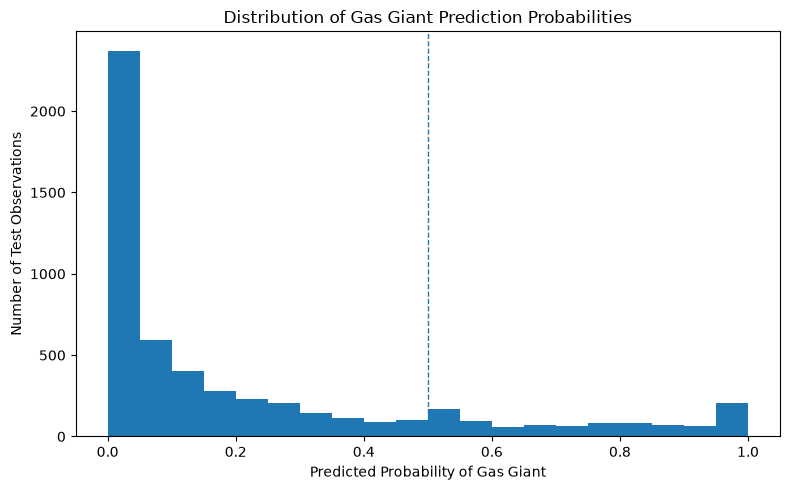

In [71]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_probability,
    bins=20
)

plt.axvline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Predicted Probability of Gas Giant"
)

plt.ylabel(
    "Number of Test Observations"
)

plt.title(
    "Distribution of Gas Giant Prediction Probabilities"
)

plt.tight_layout()

plt.show()

In [72]:
uncertain_predictions = (
    probability_analysis
    .sort_values(
        "Decision Margin"
    )
)

uncertain_predictions.head(10)

,st_teff,st_rad,st_met,Actual,Predicted,Gas Giant Probability,Correct,Decision Margin
3452,5139.00,0.85000,0.070,0,0,0.500000,True,0.000000
3944,5633.00,0.94000,-0.053,0,0,0.500000,True,0.000000
3132,6034.00,1.17900,0.240,0,0,0.500000,True,0.000000
750,3789.00,0.74800,NaN,0,0,0.500000,True,0.000000
2634,5736.00,1.07000,NaN,1,0,0.500000,False,0.000000
5106,6046.76,1.25619,NaN,1,0,0.500000,False,0.000000
1992,6383.00,1.47000,0.060,0,0,0.500000,True,0.000000
4599,5520.00,1.04000,0.385,0,0,0.500000,True,0.000000
5425,5080.00,1.04080,NaN,1,0,0.500000,False,0.000000
184,6075.00,1.33100,NaN,1,0,0.499375,False,0.000625


In [73]:
confident_errors = (
    probability_analysis[
        ~probability_analysis["Correct"]
    ]
    .sort_values(
        "Decision Margin",
        ascending=False
    )
)

confident_errors.head(10)

,st_teff,st_rad,st_met,Actual,Predicted,Gas Giant Probability,Correct,Decision Margin
5334,5703.0,1.048000,0.16,0,1,1.0,False,0.5
25,5674.0,0.820000,0.05,0,1,1.0,False,0.5
358,5618.0,0.897000,-0.22,0,1,1.0,False,0.5
351,NaN,0.637000,NaN,1,0,0.0,False,0.5
1536,5742.0,0.860000,NaN,1,0,0.0,False,0.5
2264,3350.0,0.373000,NaN,1,0,0.0,False,0.5
1603,3133.0,0.222121,NaN,1,0,0.0,False,0.5
4666,NaN,1.115000,NaN,0,1,1.0,False,0.5
4073,5894.0,0.900000,NaN,1,0,0.0,False,0.5
3217,6215.0,0.957000,-0.30,1,0,0.0,False,0.5


## Error Analysis

The model makes two important types of classification errors:

- False positives: non-gas giants classified as gas giants.
- False negatives: gas giants classified as non-gas giants.

These error groups are examined to determine whether they differ in their average stellar-property values and in the model's predicted probabilities.

This analysis is descriptive. Differences between error groups do not establish that a particular stellar property caused the classification error.

In [74]:
false_negatives = probability_analysis[
    (
        probability_analysis["Actual"]
        == 1
    )
    &
    (
        probability_analysis["Predicted"]
        == 0
    )
]

false_positives = probability_analysis[
    (
        probability_analysis["Actual"]
        == 0
    )
    &
    (
        probability_analysis["Predicted"]
        == 1
    )
]

true_positives = probability_analysis[
    (
        probability_analysis["Actual"]
        == 1
    )
    &
    (
        probability_analysis["Predicted"]
        == 1
    )
]

true_negatives = probability_analysis[
    (
        probability_analysis["Actual"]
        == 0
    )
    &
    (
        probability_analysis["Predicted"]
        == 0
    )
]

In [75]:
error_group_summary = pd.DataFrame({
    "Group": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],

    "Count": [
        len(true_negatives),
        len(false_positives),
        len(false_negatives),
        len(true_positives)
    ],

    "Mean Gas Giant Probability": [
        true_negatives[
            "Gas Giant Probability"
        ].mean(),

        false_positives[
            "Gas Giant Probability"
        ].mean(),

        false_negatives[
            "Gas Giant Probability"
        ].mean(),

        true_positives[
            "Gas Giant Probability"
        ].mean()
    ]
})

error_group_summary.round(3)

,Group,Count,Mean Gas Giant Probability
0,True Negatives,4215,0.090
1,False Positives,471,0.697
2,False Negatives,333,0.230
3,True Positives,489,0.820


In [76]:
feature_error_summary = pd.DataFrame({
    "True Negatives":
        true_negatives[
            X_test.columns
        ].mean(),

    "False Positives":
        false_positives[
            X_test.columns
        ].mean(),

    "False Negatives":
        false_negatives[
            X_test.columns
        ].mean(),

    "True Positives":
        true_positives[
            X_test.columns
        ].mean()
})

feature_error_summary.round(3)

,True Negatives,False Positives,False Negatives,True Positives
st_teff,5382.969,5634.570,5595.981,5811.743
st_rad,0.932,1.198,1.101,1.516
st_met,-0.073,0.077,0.053,0.091


In [77]:
error_rates = pd.DataFrame({
    "Actual Class": [
        "Non-Gas Giant",
        "Gas Giant"
    ],

    "Total Observations": [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ],

    "Incorrect Predictions": [
        len(false_positives),
        len(false_negatives)
    ]
})

error_rates[
    "Error Rate"
] = (
    error_rates[
        "Incorrect Predictions"
    ]
    /
    error_rates[
        "Total Observations"
    ]
)

error_rates[
    "Error Rate (%)"
] = (
    error_rates[
        "Error Rate"
    ]
    *
    100
)

error_rates.round(3)

,Actual Class,Total Observations,Incorrect Predictions,Error Rate,Error Rate (%)
0,Non-Gas Giant,4686,471,0.101,10.051
1,Gas Giant,822,333,0.405,40.511


In [78]:
decision_margin_summary = (
    probability_analysis
    .groupby("Correct")[
        "Decision Margin"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
)

decision_margin_summary.round(3)

,count,mean,median,std
Correct,,,,
False,804,0.227,0.228,0.155
True,4704,0.401,0.460,0.127


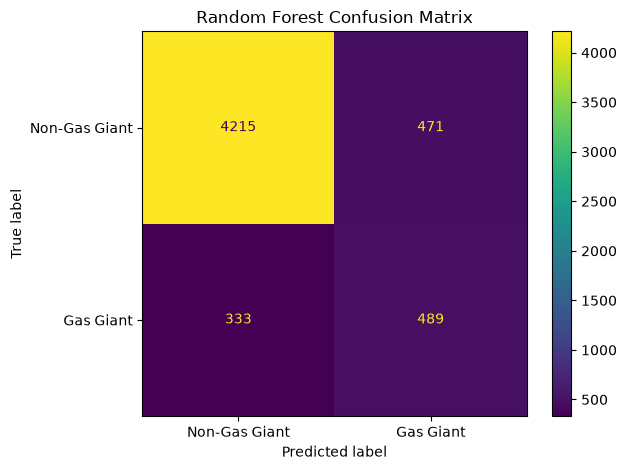

In [79]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "Non-Gas Giant",
        "Gas Giant"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.tight_layout()

plt.show()

## Interpretation

The Random Forest's final test-set performance was evaluated using predictions generated from the fixed final model selected in Notebook 03.

Cross-validation analysis examined how performance varied across five stratified folds of the training dataset. The mean, standard deviation, minimum, and maximum of each evaluation metric provide a summary of performance variability within the available dataset.

Feature interpretation was performed using both impurity-based Random Forest feature importance and permutation importance. These methods measure different aspects of model behavior. Broad agreement between them provides stronger evidence that a feature contributes to predictive performance, while disagreement may reflect feature correlation, redundancy, or differences in how the model uses the predictors.

Partial dependence analysis examined how the fitted model's average predicted probability of gas-giant classification changed as important stellar properties varied across their observed ranges. These curves describe the model's learned response patterns and should not be interpreted as evidence of causal relationships.

Prediction-probability analysis examined the model's decision margins. Observations near the 0.50 classification threshold had weaker separation between the two classes, while observations farther from the threshold reflected stronger model preferences. These probabilities should not be interpreted as calibrated probabilities of classification correctness. Probability calibration is evaluated separately in Notebook 05.

Error analysis compared true positives, true negatives, false positives, and false negatives. Differences in feature distributions between these groups may help identify regions of the available parameter space in which the model has greater difficulty distinguishing gas giants from non-gas giants.

Overall, this notebook characterizes how the final Random Forest model behaves and what predictive patterns it relies upon. The analyses do not establish causal relationships between host-star properties and planetary composition.

The model's broader generalization across alternative data splits, repeated resampling procedures, and scientifically meaningful subgroups is investigated in later robustness analyses. Feature ablation, single-feature models, SHAP analysis, and direct comparisons of the underlying astronomical data are also reserved for later notebooks.

In [80]:
print(
    "Model Interpretation and Robustness Summary"
)

print("=" * 60)

print(
    f"Test F1: "
    f"{f1_score(y_test, y_pred):.3f}"
)

print(
    f"Mean cross-validation F1: "
    f"{cv_scores['F1'].mean():.3f}"
)

print(
    f"Cross-validation F1 standard deviation: "
    f"{cv_scores['F1'].std(ddof=0):.3f}"
)

print(
    "\nMost important features by permutation importance:"
)

print(
    permutation_f1_df[
        [
            "Feature",
            "Mean F1 Decrease"
        ]
    ]
    .head(3)
    .round(4)
)

print(
    "\nMost uncertain predictions:"
)

print(
    probability_analysis
    .sort_values(
        "Decision Margin"
    )
    .head(3)[
        [
            "Gas Giant Probability",
            "Actual",
            "Predicted",
            "Decision Margin"
        ]
    ]
    .round(3)
)

print(
    "\nError counts:"
)

print(
    error_group_summary[
        [
            "Group",
            "Count"
        ]
    ]
)

Model Interpretation and Robustness Summary
Test F1: 0.549
Mean cross-validation F1: 0.536
Cross-validation F1 standard deviation: 0.010

Most important features by permutation importance:
   Feature  Mean F1 Decrease
0   st_rad            0.2933
1  st_teff            0.2370
2   st_met            0.2188

Most uncertain predictions:
      Gas Giant Probability  Actual  Predicted  Decision Margin
3452                    0.5       0          0              0.0
3944                    0.5       0          0              0.0
3132                    0.5       0          0              0.0

Error counts:
             Group  Count
0   True Negatives   4215
1  False Positives    471
2  False Negatives    333
3   True Positives    489
